In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Library explanations:
# numpy (np)                -> Numerical computing library used for arrays, matrices, and mathematical operations.
# pandas (pd)               -> Data analysis library used for creating and manipulating DataFrames and tables.
# matplotlib.pyplot (plt)   -> Visualization library used for creating plots, charts, and graphs.
# seaborn (sns)             -> Statistical data visualization library built on top of Matplotlib with enhanced graphics.
#
# make_circles              -> Generates a synthetic dataset of concentric circles, often used for classification tasks.
# SVC                       -> Support Vector Classifier, an implementation of Support Vector Machine (SVM) for classification.
#
# train_test_split          -> Splits a dataset into training and testing subsets.
# GridSearchCV              -> Performs exhaustive hyperparameter tuning using cross-validation.
#
# StandardScaler            -> Standardizes features by removing the mean and scaling to unit variance.
#
# accuracy_score            -> Calculates the classification accuracy of a model.
# confusion_matrix          -> Creates a matrix showing actual vs. predicted class labels.
# classification_report     -> Generates detailed classification metrics such as precision, recall, F1-score, and support.

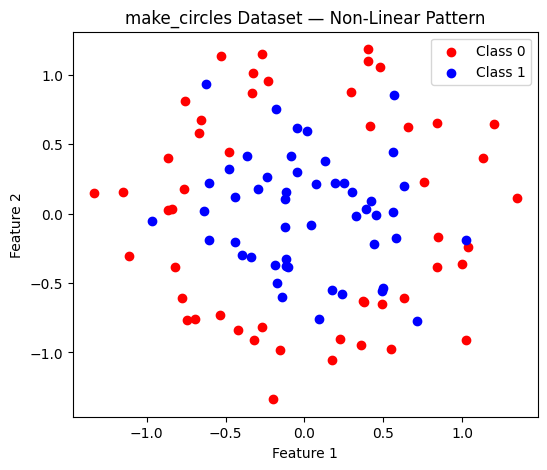

Dataset shape: (100, 2)
Class distribution: [50 50]


In [3]:
# Generate non-linearly separable circular dataset
X, y = make_circles(noise=0.2, factor=0.5, random_state=42)

# Visualize the dataset
plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="red", label="Class 0")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="blue", label="Class 1")
plt.title("make_circles Dataset — Non-Linear Pattern")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

print(f"Dataset shape: {X.shape}")
print(f"Class distribution: {np.bincount(y)}")

# Functionality:
# make_circles() -> Generates a synthetic 2D dataset consisting of two concentric circles.
#                   Commonly used to test machine learning models on non-linear classification problems.
#                   noise=0.2 adds random variation to the data points.
#                   factor=0.5 controls the size of the inner circle relative to the outer circle.
#                   random_state=42 ensures reproducible results.

# plt.figure(figsize=(6, 5)) -> Creates a new figure with a width of 6 inches and height of 5 inches.

# plt.scatter() -> Creates a scatter plot where each point represents one sample in the dataset.
#                  X-coordinate = Feature 1, Y-coordinate = Feature 2.
#                  color specifies the color of the points.
#                  label assigns a name for the legend.

# plt.title() -> Adds a title to the graph.

# plt.xlabel() -> Labels the x-axis.

# plt.ylabel() -> Labels the y-axis.

# plt.legend() -> Displays the labels for each class on the plot.

# plt.show() -> Renders and displays the figure.

# X.shape -> Returns the dimensions of the feature matrix (samples, features).

# np.bincount(y) -> Counts the number of occurrences of each class label in y.
#                   Used to check the class distribution.

In [5]:
# Check for missing values (should be none for generated dataset)
print(f"Missing values: {np.isnan(X).sum()}")

# Split first, then scale (avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# StandardScaler: fit on train, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train_scaled.shape[0]}")
print(f"Testing  samples : {X_test_scaled.shape[0]}")

Missing values: 0
Training samples : 80
Testing  samples : 20


Linear SVM Accuracy: 30.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.30      1.00      0.46         6

    accuracy                           0.30        20
   macro avg       0.15      0.50      0.23        20
weighted avg       0.09      0.30      0.14        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


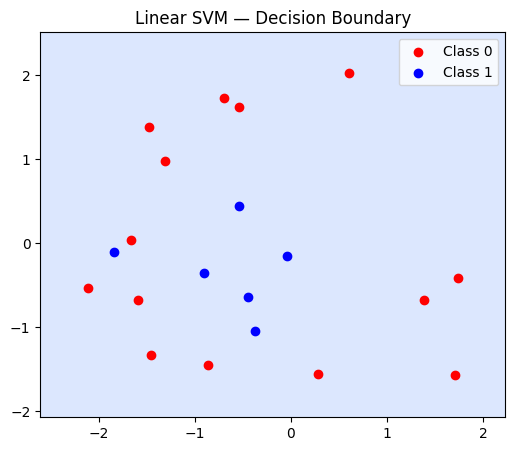

In [9]:
# Train linear SVM — expected to perform poorly on non-linear data
linear_svm = SVC(kernel="linear", random_state=42)
linear_svm.fit(X_train_scaled, y_train)
y_pred_linear = linear_svm.predict(X_test_scaled)

print(f"Linear SVM Accuracy: {accuracy_score(y_test, y_pred_linear) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear))

# Visualize decision boundary
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="red", label="Class 0")
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="blue", label="Class 1")
    plt.title(title)
    plt.legend()
    plt.show()

plot_decision_boundary(linear_svm, X_test_scaled, y_test, "Linear SVM — Decision Boundary")

# Functionality of plot_decision_boundary():
# plot_decision_boundary(model, X, y, title) -> Visualizes how a classification model separates different classes.
#
# Parameters:
# model -> Trained machine learning model used to make predictions.
# X     -> Feature dataset containing the input points.
# y     -> True class labels for the data points.
# title -> Title displayed on the plot.
#
# How the function works:
# 1. Creates a fine grid of points covering the entire feature space.
# 2. Uses the trained model to predict the class of every grid point.
# 3. Reshapes the predictions to match the grid structure.
# 4. Uses plt.contourf() to color regions according to the predicted class.
# 5. Uses plt.scatter() to overlay the actual data points.
# 6. Displays the resulting decision boundary, showing how the model separates classes.
#
# Purpose:
# This function helps visually evaluate a classifier by comparing its decision regions
# with the actual data distribution. It is especially useful for understanding whether
# a model can capture linear or non-linear patterns in the dataset.

RBF SVM Accuracy: 95.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.83      0.91         6

    accuracy                           0.95        20
   macro avg       0.97      0.92      0.94        20
weighted avg       0.95      0.95      0.95        20



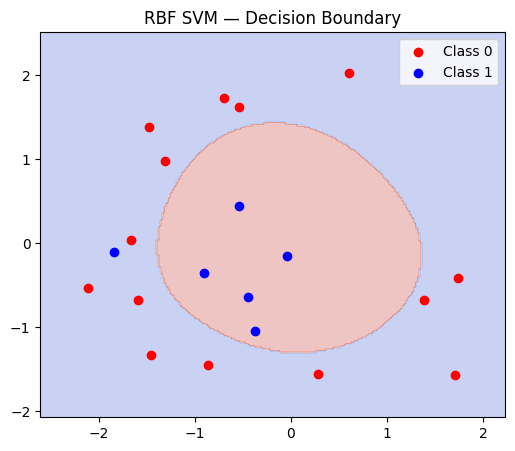

In [10]:
# RBF kernel creates circular/non-linear decision boundaries
rbf_svm = SVC(kernel="rbf", random_state=42)
rbf_svm.fit(X_train_scaled, y_train)
y_pred_rbf = rbf_svm.predict(X_test_scaled)

print(f"RBF SVM Accuracy: {accuracy_score(y_test, y_pred_rbf) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf))

plot_decision_boundary(rbf_svm, X_test_scaled, y_test, "RBF SVM — Decision Boundary")

# Functionality:
# SVC(kernel="rbf") -> Creates a Support Vector Machine using the Radial Basis Function (RBF) kernel.
#                      Unlike the linear kernel used previously, the RBF kernel can model
#                      complex non-linear relationships by transforming data into a higher-dimensional space.

# rbf_svm.fit(X_train_scaled, y_train) -> Trains the RBF SVM model using the scaled training data.

# rbf_svm.predict(X_test_scaled) -> Predicts the class labels of the test dataset.

# accuracy_score() -> Measures the percentage of correctly classified samples.

# classification_report() -> Displays precision, recall, F1-score, and support for each class.

# plot_decision_boundary() -> Same visualization function used in the previous Linear SVM cell.
#                             It generates a grid of points, predicts the class for each point,
#                             and visualizes the resulting decision regions.

# Relation to the previous cell:
# - The previous model used a Linear Kernel, which creates a straight-line decision boundary.
# - This model uses an RBF Kernel, which creates curved and non-linear decision boundaries.
# - Since the make_circles dataset contains concentric circles, the RBF kernel is expected
#   to perform significantly better than the Linear SVM.
# - Comparing the two decision boundary plots helps demonstrate why kernel selection
#   is important for non-linearly separable datasets.

Polynomial SVM Accuracy: 40.00%


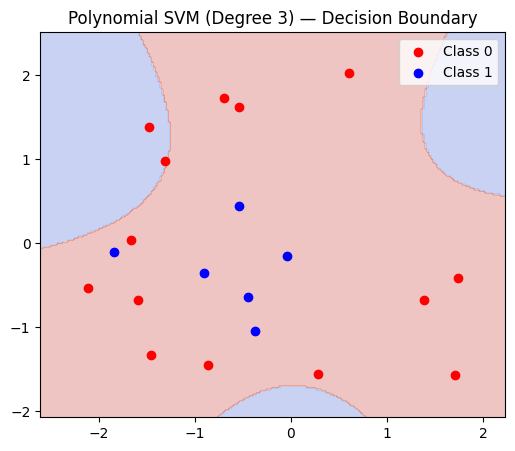

Sigmoid SVM Accuracy: 60.00%


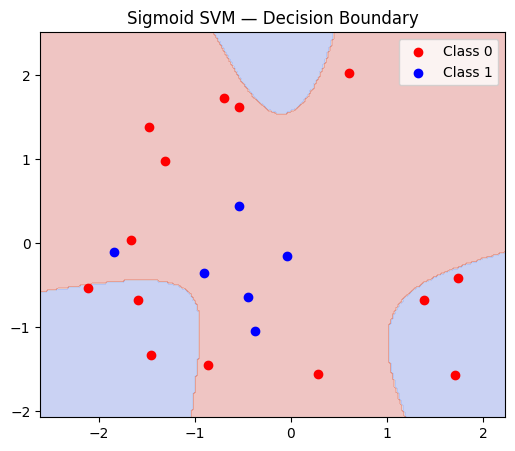


Kernel Comparison:
            Kernel  Accuracy
            Linear      30.0
               RBF      95.0
Polynomial (deg 3)      40.0
           Sigmoid      60.0


In [11]:
# Polynomial kernel
poly_svm = SVC(kernel="poly", degree=3, random_state=42)
poly_svm.fit(X_train_scaled, y_train)
y_pred_poly = poly_svm.predict(X_test_scaled)

print(f"Polynomial SVM Accuracy: {accuracy_score(y_test, y_pred_poly) * 100:.2f}%")
plot_decision_boundary(poly_svm, X_test_scaled, y_test, "Polynomial SVM (Degree 3) — Decision Boundary")

# Sigmoid kernel
sig_svm = SVC(kernel="sigmoid", random_state=42)
sig_svm.fit(X_train_scaled, y_train)
y_pred_sig = sig_svm.predict(X_test_scaled)

print(f"Sigmoid SVM Accuracy: {accuracy_score(y_test, y_pred_sig) * 100:.2f}%")
plot_decision_boundary(sig_svm, X_test_scaled, y_test, "Sigmoid SVM — Decision Boundary")

# Comparison table
results = pd.DataFrame({
    "Kernel"  : ["Linear", "RBF", "Polynomial (deg 3)", "Sigmoid"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_linear) * 100,
        accuracy_score(y_test, y_pred_rbf)    * 100,
        accuracy_score(y_test, y_pred_poly)   * 100,
        accuracy_score(y_test, y_pred_sig)    * 100
    ]
})
print("\nKernel Comparison:")
print(results.to_string(index=False))

In [12]:
# Define parameter grid to search
param_grid = {
    "kernel" : ["rbf", "poly", "sigmoid"],
    "C"      : [0.1, 1, 10, 100],
    "gamma"  : ["scale", "auto", 0.01, 0.1],
    "degree" : [2, 3, 4]   # only used when kernel="poly"
}

# GridSearchCV tries all combinations and picks the best
grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,              # 5-fold cross validation
    scoring="accuracy",
    n_jobs=-1,         # use all CPU cores
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Parameters : {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_ * 100:.2f}%")

# Functionality:
# param_grid -> Dictionary containing the hyperparameter values to be tested.
#               GridSearchCV will evaluate every possible combination of these values.

# kernel -> Specifies the type of decision boundary:
#           "rbf"     = non-linear radial basis function kernel.
#           "poly"    = polynomial kernel.
#           "sigmoid" = sigmoid kernel, similar to a neural network activation.

# C -> Regularization parameter that controls the trade-off between:
#      - minimizing classification errors
#      - maximizing the margin between classes.
#      Smaller C = simpler model, larger margin.
#      Larger C = attempts to classify more training points correctly.

# gamma -> Controls the influence of each training sample.
#          Low gamma = smoother decision boundary.
#          High gamma = more complex decision boundary.

# degree -> Degree of the polynomial kernel.
#           Only affects models when kernel="poly".

# GridSearchCV() -> Performs exhaustive hyperparameter tuning by testing
#                   all parameter combinations defined in param_grid.

# SVC(random_state=42) -> Base SVM model that GridSearchCV will optimize.

# cv=5 -> Uses 5-fold cross-validation:
#         - Training data is split into 5 parts.
#         - Model trains on 4 parts and validates on 1 part.
#         - Process repeats 5 times and results are averaged.

# scoring="accuracy" -> Uses classification accuracy as the evaluation metric.

# n_jobs=-1 -> Uses all available CPU cores to speed up the search process.

# verbose=1 -> Displays progress messages while GridSearchCV is running.

# grid_search.fit(X_train_scaled, y_train) -> Trains and evaluates every
#                                             parameter combination using
#                                             cross-validation.

# grid_search.best_params_ -> Returns the parameter combination that achieved
#                             the highest cross-validation accuracy.

# grid_search.best_score_ -> Returns the best average cross-validation accuracy.

# Relation to previous cells:
# - Previously, a Linear SVM and an RBF SVM were trained using manually selected parameters.
# - This cell automates the process of finding the optimal SVM configuration.
# - Instead of guessing the best kernel, C, gamma, and degree values,
#   GridSearchCV systematically evaluates all combinations and selects
#   the model with the best performance.
# - The best model found here will be used in the next step for final evaluation.

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best Parameters : {'C': 1, 'degree': 2, 'gamma': 'auto', 'kernel': 'poly'}
Best CV Accuracy: 86.25%


Best Model Test Accuracy: 95.00%


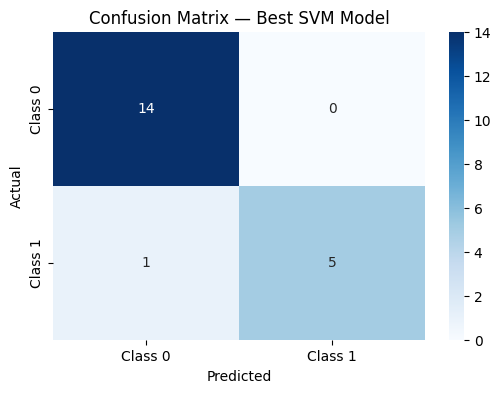


Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.83      0.91         6

    accuracy                           0.95        20
   macro avg       0.97      0.92      0.94        20
weighted avg       0.95      0.95      0.95        20



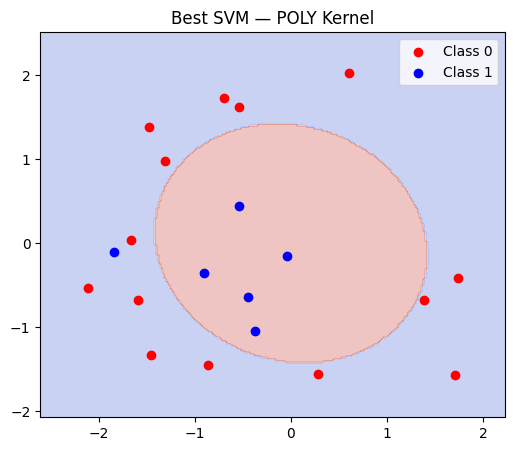

In [13]:
# Train best model found by GridSearchCV on test set
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)

print(f"Best Model Test Accuracy: {accuracy_score(y_test, y_pred_best) * 100:.2f}%")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Class 0", "Class 1"],
            yticklabels=["Class 0", "Class 1"])
plt.title("Confusion Matrix — Best SVM Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Final decision boundary
plot_decision_boundary(best_model, X_test_scaled, y_test,
                       f"Best SVM — {grid_search.best_params_['kernel'].upper()} Kernel")